# Introducción a K-Means

Este notebook está pensado para **estudiar el algoritmo K-Means paso a paso** usando un dataset de familias con **ingresos, gastos y ahorro**.

## Indicaciones
Intenta responder a estos puntos.
- Comprender qué problema resuelve K-Means.
- Explorar el dataset antes de agrupar.
- Seleccionar variables con criterio.
- Entender por qué hay que escalar los datos.
- Aplicar K-Means con distintos valores de `k`.
- Utilizar el método Elbow (del codo)
- Interpretar los centroides y los clusters.

> Nota: comenta cada resultado antes de pasar a la siguiente.

## 1. Cargar librerías y dataset

En esta primera parte cargamos:
- el dataset de familias,
- las librerías de análisis,
- y una vista inicial de los datos.

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [29]:
# Cambia la ruta si guardas el CSV en otra carpeta
df_families = pd.read_csv("05_familias_gastos_ingresos_300.csv")
df_families.head()

,id_hogar,ingreso_anual,gasto_vivienda,gasto_alimentacion,gasto_transporte,gasto_ocio,gasto_salud,gasto_educacion,ahorro
0,1,35319.00,10502.35,5293.46,5241.74,4041.16,2105.42,2977.06,5157.80
1,2,53484.00,13454.40,8395.17,6076.10,3031.31,2884.73,4554.92,15087.36
2,3,50007.61,13698.41,8949.33,4634.47,3666.31,3800.52,5091.09,10167.47
3,4,39437.43,11906.00,7375.84,5084.38,3600.76,1091.38,6025.64,4353.43
4,5,12000.00,3187.00,2718.18,1628.21,840.63,467.12,981.27,2177.59


## 2. Primer vistazo al dataset

Antes de usar cualquier algoritmo, hay que entender los datos:
- cuántas filas hay,
- qué variables tenemos,
- si hay valores nulos,
- y qué magnitudes manejamos.

In [30]:
#filas: shape de 0 muestra filas, de 1 muestra columnas
df_families.shape[0]

300

In [31]:
#variables
df_families.columns

Index(['id_hogar', 'ingreso_anual', 'gasto_vivienda', 'gasto_alimentacion',
       'gasto_transporte', 'gasto_ocio', 'gasto_salud', 'gasto_educacion',
       'ahorro'],
      dtype='object')

In [32]:
#cómo son los datos
df_families.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   id_hogar            300 non-null    int64  
 1   ingreso_anual       300 non-null    float64
 2   gasto_vivienda      300 non-null    float64
 3   gasto_alimentacion  300 non-null    float64
 4   gasto_transporte    300 non-null    float64
 5   gasto_ocio          300 non-null    float64
 6   gasto_salud         300 non-null    float64
 7   gasto_educacion     300 non-null    float64
 8   ahorro              300 non-null    float64
dtypes: float64(8), int64(1)
memory usage: 21.2 KB


In [33]:
#hay nulos o no, no hay nulos, se ve en la info de arriba, y también se puede comprobar con el siguiente código
df_families.isnull().sum()

id_hogar              0
ingreso_anual         0
gasto_vivienda        0
gasto_alimentacion    0
gasto_transporte      0
gasto_ocio            0
gasto_salud           0
gasto_educacion       0
ahorro                0
dtype: int64

## 3. Comprender el problema

K-Means es un algoritmo de **aprendizaje no supervisado**.
Eso significa que:
- no hay una columna objetivo,
- no hay etiquetas previas,
- y el objetivo es **descubrir grupos similares** en los datos.

En este caso queremos detectar perfiles de familias, por ejemplo:
- Familia tipo 1: .....
- Familia tipo 2: .....
- Familia tipo 3: .....

## 4. Selección inicial de variables

No siempre interesa usar todas las columnas desde el principio.
Para empezar, vamos a observar una relación muy intuitiva:

- `ingreso_anual`
- `gasto_ocio`

Esto permite una primera visualización sencilla del problema.

In [34]:
X_simple = df_families[["ingreso_anual", "gasto_ocio"]]
X_simple.head()

,ingreso_anual,gasto_ocio
0,35319.00,4041.16
1,53484.00,3031.31
2,50007.61,3666.31
3,39437.43,3600.76
4,12000.00,840.63


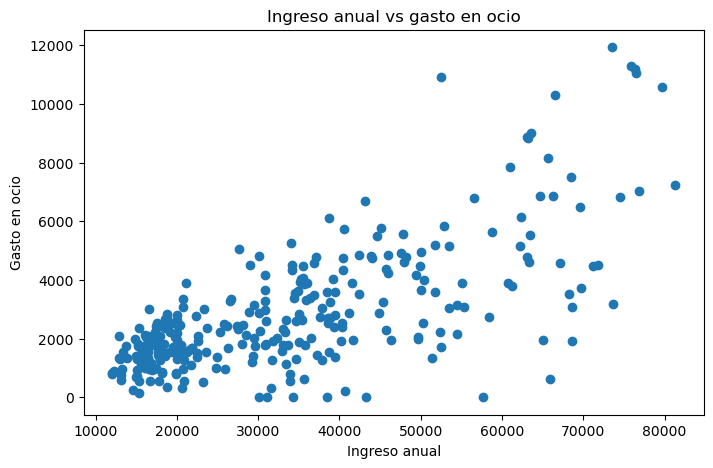

In [35]:
plt.figure(figsize=(8,5))
plt.scatter(df_families["ingreso_anual"], df_families["gasto_ocio"])
plt.xlabel("Ingreso anual")
plt.ylabel("Gasto en ocio")
plt.title("Ingreso anual vs gasto en ocio")
plt.show()

### Cuestiones
1. ¿Se distinguen grupos visualmente?

Podemos ver en lineas generales que la tendencia a gastar en ocio suele aumentar mientras aumenta el ingreso, el monton de la izquierda se distingue claramente
pero luego empieza a haber algo mas de dispersión en los datos y menos cantidad.

2. ¿Parece haber familias con ingresos parecidos pero distinto gasto en ocio?
Si, podemos ver en la linea que hay familias con un gasto de ocio diferente cuanto mas nos desplazamos en la derecha, esto se puede deber por ejemplo a la edad de las personas con esos ingresos, por darle una posible explicación.

3. ¿Crees que con solo dos variables será suficiente?
Creo que no, hay diferentes tipos de gastos, que podrían hacer que cambien los grupos, ya que quizás gente que gaste poco en ocio gasta mas en vivienda por ejemplo, en los grupos mas bajos igual no afecta tanto, pero probablemente en gente con mayores ingresos si.

## 5. Primer K-Means con `k = 3`

Empieza con una prueba sencilla.
Aquí el algoritmo:
1. Fija un número de grupos `k`,
2. Busca centroides,
3. Asigna cada familia al centroide más cercano.

In [36]:
kmeans_3 = KMeans(n_clusters=3, random_state=42, n_init=10)
kmeans_3.fit(X_simple)

labels_3 = kmeans_3.labels_
centroides_3 = kmeans_3.cluster_centers_

print("Centroides:")
print(centroides_3)

Centroides:
[[18685.46454545  1672.61075758]
 [63753.68980769  5573.08115385]
 [37749.7662069   2994.94077586]]


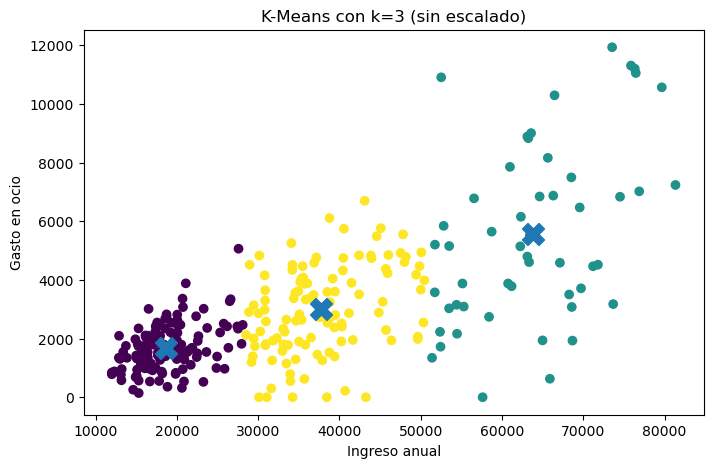

In [37]:
plt.figure(figsize=(8,5))
plt.scatter(X_simple["ingreso_anual"], X_simple["gasto_ocio"], c=labels_3)
plt.scatter(centroides_3[:,0], centroides_3[:,1], marker="X", s=250)
plt.xlabel("Ingreso anual")
plt.ylabel("Gasto en ocio")
plt.title("K-Means con k=3 (sin escalado)")
plt.show()

## 6. Interpretar los centroides

Los centroides representan el “centro” de cada grupo.

Conviene pasarlos a tabla para interpretarlos mejor.

In [38]:
pd.DataFrame(centroides_3, columns=X_simple.columns)

,ingreso_anual,gasto_ocio
0,18685.464545,1672.610758
1,63753.689808,5573.081154
2,37749.766207,2994.940776


### Cuestione
1. ¿Qué clúster tiene el mayor ingreso medio?
El cluster numero 1 tiene un mayor ingresio medio, al igual que también el mayor gasto medio en ocio, demostrando que en promedio la tendencia suele ser aumentativa

2. ¿Cuál tiene menor gasto en ocio?
El cluster numero 0 tiene el menor ingreso y menor gasto de ocio, demostrando nuevamente lo dicho en el punto anterior

3. ¿Cómo describirías cada grupo con palabras?
El primer grupo de gente con menos ingresos y menos gasto de ocio son las familias con un presupuesto mas limitado, el grupo con mayor gasto e ingresos, son familias con un presupuesto y libertad de gasto alta, y el grupo medio, del cluster 2 son familias de presupuesto medio y libertad de gasto media. 


## 7. Probar distintos valores de `k`

K-Means necesita que indiques el número de grupos.
Repite el proceso con distintos valores para ver cómo cambia el resultado.

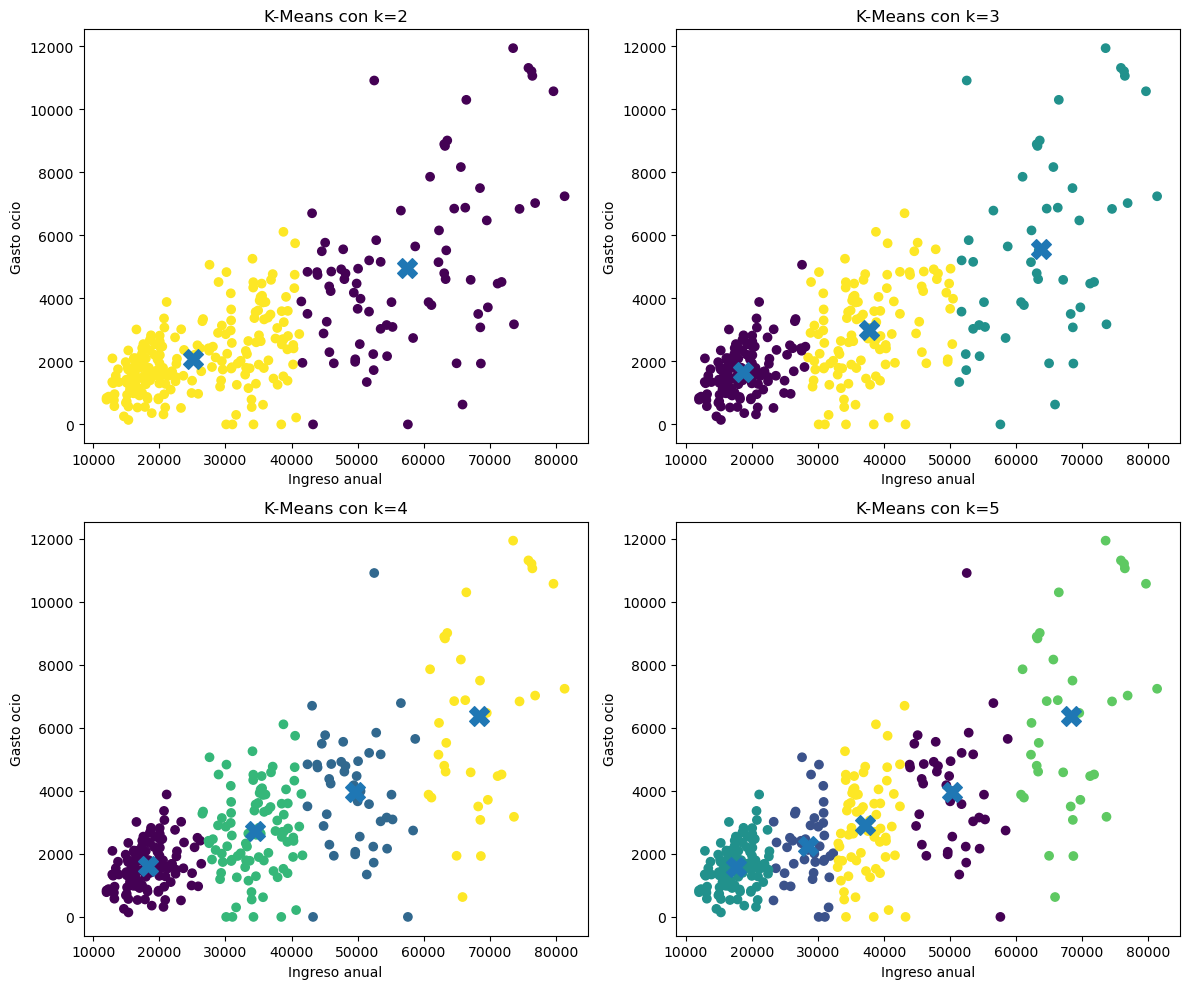

In [39]:
valores_k = [2, 3, 4, 5]

plt.figure(figsize=(12, 10))

for i, k in enumerate(valores_k, start=1):
    modelo = KMeans(n_clusters=k, random_state=42, n_init=10)
    etiquetas = modelo.fit_predict(X_simple)
    centros = modelo.cluster_centers_

    plt.subplot(2, 2, i)
    plt.scatter(X_simple["ingreso_anual"], X_simple["gasto_ocio"], c=etiquetas)
    plt.scatter(centros[:,0], centros[:,1], marker="X", s=200)
    plt.title(f"K-Means con k={k}")
    plt.xlabel("Ingreso anual")
    plt.ylabel("Gasto ocio")

plt.tight_layout()
plt.show()

## 8. Método Elbow (Método del codo)

Una forma clásica de elegir `k` es calcular la **inercia** para distintos valores.
La inercia mide, en términos simples, lo compactos que quedan los grupos.

Buscamos el punto en que la mejora deja de ser tan grande.

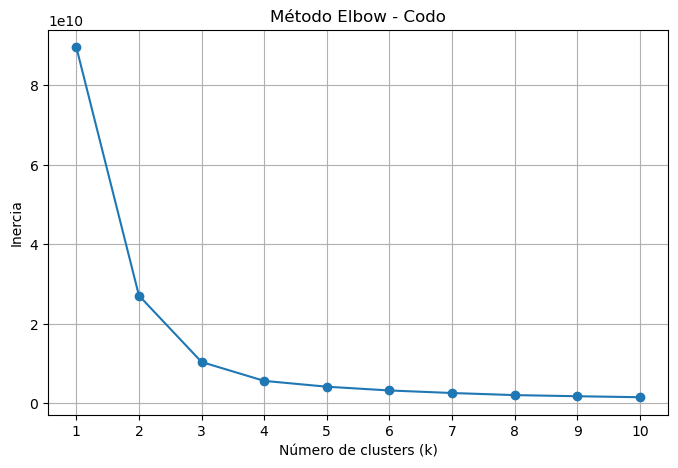

In [40]:
#aquí debe ir el código del Método Elbow - Codo
inercia = []
valores_k = range(1, 11)
for k in valores_k:
    modelo = KMeans(n_clusters=k, random_state=42, n_init=10)
    modelo.fit(X_simple)
    inercia.append(modelo.inertia_)
plt.figure(figsize=(8,5))
plt.plot(valores_k, inercia, marker="o")
plt.title("Método Elbow - Codo")
plt.xlabel("Número de clusters (k)")
plt.ylabel("Inercia")
plt.xticks(valores_k)
plt.grid()
plt.show()



### Cuestiones
1. ¿En qué valor de `k` parece estar el “codo”?
El momento en el que k parece estar en el codo es en el 3, esto no significa que sea la respuesta mas correcta ya que también depende de como lo interpretemos.

2. ¿Ese valor coincide con lo que observabas en la gráfica?
Aparentemente si, todo depende de como lo interpretemos, pero creo que en una observación general se puede interpretar facilmente que hay 3 grupos de personas, pero no hay una sola respuesta correcta.

3. ¿Crees que hay una única respuesta correcta?
La verdad que creo que no, debido a lo que vengo hablando, de que todo depende de la interpretación de los datos que realicemos, podemos dividir en 3,4,5 clusters si somos capaces de dar una justificación correcta que se adapte al problema que tratemos de resolver.

## 9. ¿Por qué es importante escalar?

K-Means trabaja con distancias.
Si una variable tiene valores mucho más grandes que otra, dominará el resultado.

Lo puedes comprobar ampliando las variables:
- ingresos,
- varios tipos de gasto,
- ahorro.

In [41]:
columnas_modelo = [
    "ingreso_anual",
    "gasto_vivienda",
    "gasto_alimentacion",
    "gasto_transporte",
    "gasto_ocio",
    "gasto_salud",
    "gasto_educacion",
    "ahorro"
]

X = df_families[columnas_modelo]
X.head()

,ingreso_anual,gasto_vivienda,gasto_alimentacion,gasto_transporte,gasto_ocio,gasto_salud,gasto_educacion,ahorro
0,35319.00,10502.35,5293.46,5241.74,4041.16,2105.42,2977.06,5157.80
1,53484.00,13454.40,8395.17,6076.10,3031.31,2884.73,4554.92,15087.36
2,50007.61,13698.41,8949.33,4634.47,3666.31,3800.52,5091.09,10167.47
3,39437.43,11906.00,7375.84,5084.38,3600.76,1091.38,6025.64,4353.43
4,12000.00,3187.00,2718.18,1628.21,840.63,467.12,981.27,2177.59


In [42]:
X.describe().T

,count,mean,std,min,25%,50%,75%,max
ingreso_anual,300.0,33868.820233,17169.230976,12000.00,18733.9400,30962.135,43409.1550,81330.33
gasto_vivienda,300.0,10126.577700,5234.255944,3187.00,5650.7275,9284.880,13350.4350,24990.75
gasto_alimentacion,300.0,6260.093467,3430.261648,1885.87,3411.5100,5600.565,8076.6900,17029.32
gasto_transporte,300.0,3399.638000,2017.642022,655.81,1834.5550,2815.020,4635.6850,11019.70
gasto_ocio,300.0,2859.993233,2149.923506,0.00,1447.8325,2266.845,3805.7775,11935.32
gasto_salud,300.0,2008.935567,1284.444677,0.00,1141.7275,1685.030,2523.5525,7893.35
gasto_educacion,300.0,2383.226000,1634.672553,0.00,1264.5775,1989.195,3086.0750,9547.87
ahorro,300.0,6830.356533,4589.870824,-1084.03,3449.3725,5539.920,9734.2025,25817.67


Observa que:
- `ingreso_anual` tiene una magnitud muy superior,
- y algunas variables de gasto tienen escalas bastante distintas.

Por eso vamos a comparar el clustering:
1. **sin escalado**
2. **con escalado**

In [43]:
modelo_sin_escalar = KMeans(n_clusters=3, random_state=42, n_init=10)
labels_sin_escalar = modelo_sin_escalar.fit_predict(X)

df_families["cluster_sin_escalar"] = labels_sin_escalar
df_families.groupby("cluster_sin_escalar")[columnas_modelo].mean().round(2)

,ingreso_anual,gasto_vivienda,gasto_alimentacion,gasto_transporte,gasto_ocio,gasto_salud,gasto_educacion,ahorro
cluster_sin_escalar,,,,,,,,
0,36687.48,11021.95,6686.03,3819.94,2944.20,2163.72,2574.52,7477.13
1,61909.99,18339.81,11673.12,5979.66,5293.97,3645.94,4334.50,12642.99
2,18541.72,5578.23,3401.37,1853.22,1665.37,1122.42,1320.78,3600.33


In [44]:
scaler = StandardScaler()
X_escalado = scaler.fit_transform(X)

modelo_escalado = KMeans(n_clusters=3, random_state=42, n_init=10)
labels_escalado = modelo_escalado.fit_predict(X_escalado)

df_families["cluster_escalado"] = labels_escalado
df_families.groupby("cluster_escalado")[columnas_modelo].mean().round(2)

,ingreso_anual,gasto_vivienda,gasto_alimentacion,gasto_transporte,gasto_ocio,gasto_salud,gasto_educacion,ahorro
cluster_escalado,,,,,,,,
0,63685.94,18924.72,12117.77,6284.49,5740.63,3922.85,4616.86,12078.62
1,18549.74,5593.97,3403.43,1847.88,1640.81,1117.76,1307.80,3638.09
2,37825.18,11307.53,6870.39,3858.47,2957.31,2162.25,2600.79,8068.45


## 10. Comparación de resultados

Ahora compara las medias de cada cluster:
- ¿son más coherentes tras escalar?
Puede ser que haga que los datos sean mas centralizados y estén mejor precisados, pero aparentemente para la cantidad de datos que tenemos, por lo que podemos ver, el escalado no presenta una diferencia considerable con los datos sin realizar esta tecnica.

- ¿parece que el modelo recoge mejor el comportamiento global de las familias?
Por lo que parece, al no haber una diferencia entre los datos va a recoger los datos de una forma similar muy probablemente.

In [45]:
print("Distribución de familias por cluster (sin escalar):")
print(df_families["cluster_sin_escalar"].value_counts().sort_index())

print("\nDistribución de familias por cluster (escalado):")
print(df_families["cluster_escalado"].value_counts().sort_index())

Distribución de familias por cluster (sin escalar):
cluster_sin_escalar
0    110
1     60
2    130
Name: count, dtype: int64

Distribución de familias por cluster (escalado):
cluster_escalado
0     51
1    130
2    119
Name: count, dtype: int64


## 11. Centroides del modelo escalado

Como los centroides escalados son difíciles de interpretar directamente,
vamos a devolverlos a la escala original.

In [46]:
centroides_escalados = modelo_escalado.cluster_centers_
centroides_originales = scaler.inverse_transform(centroides_escalados)

pd.DataFrame(centroides_originales, columns=columnas_modelo).round(2)

,ingreso_anual,gasto_vivienda,gasto_alimentacion,gasto_transporte,gasto_ocio,gasto_salud,gasto_educacion,ahorro
0,63685.94,18924.72,12117.77,6284.49,5740.63,3922.85,4616.86,12078.62
1,18549.74,5593.97,3403.43,1847.88,1640.81,1117.76,1307.80,3638.09
2,37825.18,11307.53,6870.39,3858.47,2957.31,2162.25,2600.79,8068.45


### Cuestiones
1. ¿Qué clúster representa familias con más ingresos?
El cluster 0 es el representativo de las familias con mas ingreso, que también es el que presenta a menos familias.

2. ¿Qué clúster parece más vulnerable?
El cluster con menos ingresos, tiene una buena cantidad de gastos y el ahorro es bastante bajo en comparación a los otros 2 clusteres.

3. ¿Cuál parece más ahorrador?
El cluster con mas ingresos, aunque claro, teniendo en cuenta que es más sencillo ahorrar teniendo una mayor cantidad de ingresos, quizás en relacion el cluster que mejor ahorra es el medio

4. ¿Ves relación entre ingresos altos y mayor gasto en algunas categorías?
Si, en todas las categorias el cluster que mas ingresa es el que mas gasta, en algunos la diferencia es bastante mayor, en otros igual no es tanta, pero siguen siendo los que más.

## 12. Interpretación final de clusters

Redacta una interpretación breve de cada cluster.

Modelo de ejemplo:

- **Cluster A**: familias con ingresos bajos y una libertad de gasto bastante limitada
- **Cluster B**: familias con un ingreso medio y una libertad de gasto medio
- **Cluster C**: familias con un ingreso alto y una libertad de gasto superior

Lo importante no es solo ejecutar K-Means, sino **dar sentido a los grupos**.

## 13. Actividad de ampliación

Prueba alguna de estas variantes:
- usar solo ingresos y ahorro,
- usar ingresos, vivienda, alimentación y ocio,
- probar `k = 4`,
- comparar resultados con y sin la variable `ahorro`,
- detectar si algunos hogares quedan en clusters poco claros.

Esto te ayudará a entender que en Aprendizaje No Supervisado las decisiones sobre variables y preparación de datos cambian el resultado.
> Resumiendo: K-Means no “descubre la verdad”; propone agrupaciones a partir de cómo le damos los datos.

In [47]:
# Cambia la ruta si guardas el CSV en otra carpeta
df_families2 = pd.read_csv("05_familias_gastos_ingresos_300.csv")
df_families2.head()

,id_hogar,ingreso_anual,gasto_vivienda,gasto_alimentacion,gasto_transporte,gasto_ocio,gasto_salud,gasto_educacion,ahorro
0,1,35319.00,10502.35,5293.46,5241.74,4041.16,2105.42,2977.06,5157.80
1,2,53484.00,13454.40,8395.17,6076.10,3031.31,2884.73,4554.92,15087.36
2,3,50007.61,13698.41,8949.33,4634.47,3666.31,3800.52,5091.09,10167.47
3,4,39437.43,11906.00,7375.84,5084.38,3600.76,1091.38,6025.64,4353.43
4,5,12000.00,3187.00,2718.18,1628.21,840.63,467.12,981.27,2177.59


In [49]:
X_simple = df_families2[["ingreso_anual", "ahorro", "gasto_alimentacion","gasto_ocio"]]
X_simple.head()

,ingreso_anual,ahorro,gasto_alimentacion,gasto_ocio
0,35319.00,5157.80,5293.46,4041.16
1,53484.00,15087.36,8395.17,3031.31
2,50007.61,10167.47,8949.33,3666.31
3,39437.43,4353.43,7375.84,3600.76
4,12000.00,2177.59,2718.18,840.63


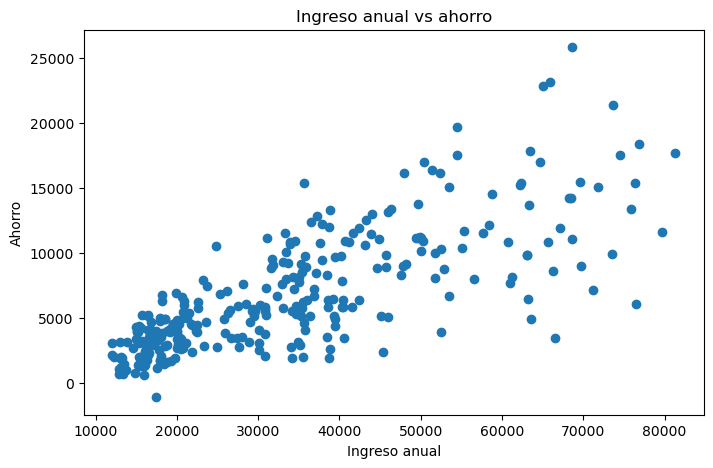

In [53]:
plt.figure(figsize=(8,5))
plt.scatter(df_families2["ingreso_anual"], df_families2["ahorro"])
plt.xlabel("Ingreso anual")
plt.ylabel("Ahorro")
plt.title("Ingreso anual vs ahorro")
plt.show()

In [54]:
kmeans_4 = KMeans(n_clusters=4, random_state=42, n_init=10)
kmeans_4.fit(X_simple)

labels_4 = kmeans_4.labels_
centroides_4 = kmeans_4.cluster_centers_

print("Centroides:")
print(centroides_4)

Centroides:
[[49575.00545455 11114.50931818  8998.79681818  3886.24681818]
 [18067.13463415  3530.32097561  3312.20390244  1593.18170732]
 [68361.58971429 13172.96771429 13042.47028571  6380.824     ]
 [34330.94520408  6783.52244898  6308.09632653  2731.7644898 ]]


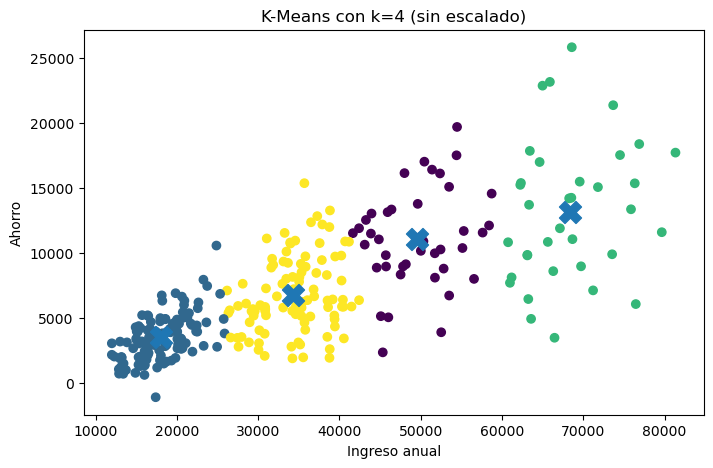

In [56]:
plt.figure(figsize=(8,5))
plt.scatter(X_simple["ingreso_anual"], X_simple["ahorro"], c=labels_4)
plt.scatter(centroides_4[:,0], centroides_4[:,1], marker="X", s=250)
plt.xlabel("Ingreso anual")
plt.ylabel("Ahorro")
plt.title("K-Means con k=4 (sin escalado)")
plt.show()

Centroides en escala original:
   ingreso_anual    ahorro  gasto_alimentacion  gasto_ocio
0       67244.74   8959.06            13031.76     9411.95
1       19205.82   3662.08             3506.33     1652.22
2       38622.38   7867.83             7002.23     3141.54
3       62860.08  15302.65            11983.10     3935.86

Distribución de familias por cluster:
0     15
1    138
2    113
3     34
Name: count, dtype: int64


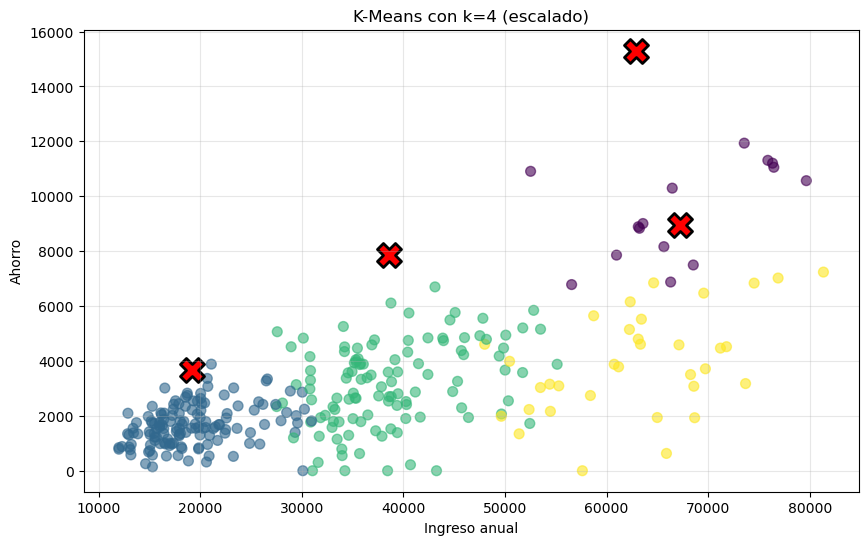

In [61]:
# Aplicar K-Means con k=4 al dataset escalado
scaler_new = StandardScaler()
X_simple_escalado = scaler_new.fit_transform(X_simple)

modelo_escalado_simple = KMeans(n_clusters=4, random_state=42, n_init=10)
labels_escalado_simple = modelo_escalado_simple.fit_predict(X_simple_escalado)

# Obtener centroides en escala original
centroides_escalados_simple = modelo_escalado_simple.cluster_centers_
centroides_originales_simple = scaler_new.inverse_transform(centroides_escalados_simple)

print("Centroides en escala original:")
print(pd.DataFrame(centroides_originales_simple, columns=X_simple.columns).round(2))

print("\nDistribución de familias por cluster:")
print(pd.Series(labels_escalado_simple).value_counts().sort_index())

# Visualizar
plt.figure(figsize=(10, 6))
plt.scatter(X_simple["ingreso_anual"], X_simple["gasto_ocio"], c=labels_escalado_simple, s=50, alpha=0.6)
plt.scatter(centroides_originales_simple[:, 0], centroides_originales_simple[:, 1], 
            marker="X", s=300, c='red', edgecolors='black', linewidth=2)
plt.xlabel("Ingreso anual")
plt.ylabel("Ahorro")
plt.title("K-Means con k=4 (escalado)")
plt.grid(True, alpha=0.3)
plt.show()